#Machine learning aplicado a estadística de youtube
El objetivo del trabajo es aplicar ML al trabajo de la Act_2. concrétamente 3 modelos:


*   Modelo de regresión lineal aplicadoa los vídeos
*   Clustering de los canales
*   Análisis de sentimiento de las descripciones de los vídeos

Comporbaremos si nuestra hipótesis del trabajo anterior se cumple con los modelos hechos, y de paso analizaremos el tipo de lenguaje que se emplea en estos vídeos.

Una vez terminado el análisis, vamos a analizar la interpretabilidad de los modelos para ver qué características consideran las más importantes a la hora de modelizar los datos.




## Bloque 1: Modelo de regresión

Empezamos leyendo los datos desde drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/My Drive/Colab Notebooks/Comp_AV/archivos_CSV/"
import pandas as pd
df1 = pd.read_csv(path + "youtube_tech_channels_20251120_133753.csv")
df2 = pd.read_csv(path + "youtube_tech_videos_20251120_133004.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ch = df1.copy()
vd = df2.copy()

Repasamos la estructura de los datos:

In [ ]:
ch.head()
ch.info()
ch.describe()
vd.head()
vd.info()
vd.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_id        130 non-null    object
 1   channel_name      130 non-null    object
 2   description       127 non-null    object
 3   subscribers       130 non-null    int64 
 4   total_views       130 non-null    int64 
 5   total_videos      130 non-null    int64 
 6   created_date      130 non-null    object
 7   country           116 non-null    object
 8   uploads_playlist  130 non-null    object
 9   scraped_at        130 non-null    object
dtypes: int64(3), object(7)
memory usage: 10.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           1300 non-null   object
 1   title              1300 non-null   obje

,views,likes,comments
count,1.300000e+03,1300.000000,1300.000000
mean,1.394824e+05,2868.888462,133.875385
std,2.299066e+06,20527.502375,757.578859
min,0.000000e+00,0.000000,0.000000
25%,8.532500e+02,24.000000,1.000000
50%,3.327500e+03,104.000000,8.000000
75%,1.814900e+04,624.500000,49.000000
max,7.960118e+07,477913.000000,16969.000000


Importante: todo el análisis se va a hacer eliminado priemro el canal "linus tech tips" se sale tanto de la norma dentro del dataframe que arrastraría irremediablemente los moddelosa predicciones erroneas.
Antes de empezar purgamos los datos asociados en los dataframes:

In [ ]:
ch_fil = ch[ch['channel_id'] != 'UCXuqSBlHAE6Xw-yeJA0Tunw']
display(ch_fil.head())
ch_fil.info()

,channel_id,channel_name,description,subscribers,total_views,total_videos,created_date,country,uploads_playlist,scraped_at
1,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286
2,UChIZGfcnjHI0DG4nweWEduw,TechSource,Join the Discord Server:\nhttps://discord.gg/T...,4010000,870967915,1897,2010-01-24T22:34:11Z,US,UUhIZGfcnjHI0DG4nweWEduw,2025-11-20T13:37:53.306286
3,UC4SVo0Ue36XCfOyb5Lh1viQ,Bro Code,Coding bootcamps HATE HIM! 🗿\n,2990000,178609297,1000,2019-10-10T14:40:46.568078Z,US,UU4SVo0Ue36XCfOyb5Lh1viQ,2025-11-20T13:37:53.306286
4,UCVeW9qkBjo3zosnqUbG7CFw,John Hammond,Free Cybersecurity Education and Ethical Hacking.,2080000,82120292,1740,2011-02-06T03:59:46Z,US,UUVeW9qkBjo3zosnqUbG7CFw,2025-11-20T13:37:53.306286
5,UCeeFfhMcJa1kjtfZAGskOCA,TechLinked,"TechLinked keeps you up to date with a fast, f...",1990000,628661984,1214,2018-05-03T19:49:25Z,CA,UUeeFfhMcJa1kjtfZAGskOCA,2025-11-20T13:37:53.306286


<class 'pandas.core.frame.DataFrame'>
Index: 129 entries, 1 to 129
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_id        129 non-null    object
 1   channel_name      129 non-null    object
 2   description       126 non-null    object
 3   subscribers       129 non-null    int64 
 4   total_views       129 non-null    int64 
 5   total_videos      129 non-null    int64 
 6   created_date      129 non-null    object
 7   country           115 non-null    object
 8   uploads_playlist  129 non-null    object
 9   scraped_at        129 non-null    object
dtypes: int64(3), object(7)
memory usage: 11.1+ KB


In [ ]:
vd_fil = vd[vd['channel_id'] != 'UCXuqSBlHAE6Xw-yeJA0Tunw']
display(vd_fil.head())
vd_fil.info()

,video_id,title,published_at,views,likes,comments,duration,thumbnail,video_url,channel_id,channel_name,scraped_at,duration_readable
10,bshe96X5KkA,AI Course for Developers - Build AI-Powered Apps,2025-08-26T12:30:47Z,22527,779,12,PT1M6S,https://i.ytimg.com/vi/bshe96X5KkA/hqdefault.jpg,https://www.youtube.com/watch?v=bshe96X5KkA,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,2025-11-20T13:37:53.306773,1:06
11,PtETUYa3i2Q,AI Course for Developers – Build AI-Powered Ap...,2025-08-25T12:30:06Z,86488,2908,210,PT2H25M40S,https://i.ytimg.com/vi/PtETUYa3i2Q/hqdefault.jpg,https://www.youtube.com/watch?v=PtETUYa3i2Q,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,2025-11-20T13:37:53.306773,2:25:40
12,V7TMkZH1AkM,A Practical AI Course for Developers is Coming...,2025-08-18T23:46:05Z,32511,1621,160,PT51S,https://i.ytimg.com/vi/V7TMkZH1AkM/hqdefault.jpg,https://www.youtube.com/watch?v=V7TMkZH1AkM,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,2025-11-20T13:37:53.306773,0:51
13,h4FRpDGuJyI,"Microsoft laid off 6,000 people… but why?",2025-05-20T11:30:41Z,93922,4340,377,PT3M53S,https://i.ytimg.com/vi/h4FRpDGuJyI/hqdefault.jpg,https://www.youtube.com/watch?v=h4FRpDGuJyI,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,2025-11-20T13:37:53.306773,3:53
14,EWd3_I4X32g,Spring Boot Project: Build a REST API for an E...,2025-04-16T21:49:36Z,161445,2953,136,PT2H17S,https://i.ytimg.com/vi/EWd3_I4X32g/hqdefault.jpg,https://www.youtube.com/watch?v=EWd3_I4X32g,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,2025-11-20T13:37:53.306773,2:00:17


<class 'pandas.core.frame.DataFrame'>
Index: 1290 entries, 10 to 1299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           1290 non-null   object
 1   title              1290 non-null   object
 2   published_at       1290 non-null   object
 3   views              1290 non-null   int64 
 4   likes              1290 non-null   int64 
 5   comments           1290 non-null   int64 
 6   duration           1290 non-null   object
 7   thumbnail          1290 non-null   object
 8   video_url          1290 non-null   object
 9   channel_id         1290 non-null   object
 10  channel_name       1290 non-null   object
 11  scraped_at         1290 non-null   object
 12  duration_readable  1290 non-null   object
dtypes: int64(3), object(10)
memory usage: 141.1+ KB


Una vez filtrado, hacemos la unión:

In [ ]:
df_unif = pd.merge(vd_fil, ch_fil, on='channel_id')
df_unif.head()
df_unif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290 entries, 0 to 1289
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           1290 non-null   object
 1   title              1290 non-null   object
 2   published_at       1290 non-null   object
 3   views              1290 non-null   int64 
 4   likes              1290 non-null   int64 
 5   comments           1290 non-null   int64 
 6   duration           1290 non-null   object
 7   thumbnail          1290 non-null   object
 8   video_url          1290 non-null   object
 9   channel_id         1290 non-null   object
 10  channel_name_x     1290 non-null   object
 11  scraped_at_x       1290 non-null   object
 12  duration_readable  1290 non-null   object
 13  channel_name_y     1290 non-null   object
 14  description        1260 non-null   object
 15  subscribers        1290 non-null   int64 
 16  total_views        1290 non-null   int64 


In [ ]:
df_unif.head()

,video_id,title,published_at,views,likes,comments,duration,thumbnail,video_url,channel_id,...,duration_readable,channel_name_y,description,subscribers,total_views,total_videos,created_date,country,uploads_playlist,scraped_at_y
0,bshe96X5KkA,AI Course for Developers - Build AI-Powered Apps,2025-08-26T12:30:47Z,22527,779,12,PT1M6S,https://i.ytimg.com/vi/bshe96X5KkA/hqdefault.jpg,https://www.youtube.com/watch?v=bshe96X5KkA,UCWv7vMbMWH4-V0ZXdmDpPBA,...,1:06,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286
1,PtETUYa3i2Q,AI Course for Developers – Build AI-Powered Ap...,2025-08-25T12:30:06Z,86488,2908,210,PT2H25M40S,https://i.ytimg.com/vi/PtETUYa3i2Q/hqdefault.jpg,https://www.youtube.com/watch?v=PtETUYa3i2Q,UCWv7vMbMWH4-V0ZXdmDpPBA,...,2:25:40,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286
2,V7TMkZH1AkM,A Practical AI Course for Developers is Coming...,2025-08-18T23:46:05Z,32511,1621,160,PT51S,https://i.ytimg.com/vi/V7TMkZH1AkM/hqdefault.jpg,https://www.youtube.com/watch?v=V7TMkZH1AkM,UCWv7vMbMWH4-V0ZXdmDpPBA,...,0:51,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286
3,h4FRpDGuJyI,"Microsoft laid off 6,000 people… but why?",2025-05-20T11:30:41Z,93922,4340,377,PT3M53S,https://i.ytimg.com/vi/h4FRpDGuJyI/hqdefault.jpg,https://www.youtube.com/watch?v=h4FRpDGuJyI,UCWv7vMbMWH4-V0ZXdmDpPBA,...,3:53,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286
4,EWd3_I4X32g,Spring Boot Project: Build a REST API for an E...,2025-04-16T21:49:36Z,161445,2953,136,PT2H17S,https://i.ytimg.com/vi/EWd3_I4X32g/hqdefault.jpg,https://www.youtube.com/watch?v=EWd3_I4X32g,UCWv7vMbMWH4-V0ZXdmDpPBA,...,2:00:17,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286


Antes de empezar con el ML, hay que alterar algunos datos para que el código los procese bien:

In [ ]:
import re
import numpy as np

# 1. Calcular la longitud del título del video
df_unif['title_length'] = df_unif['title'].apply(len)

# 2. Convertir columnas de fecha a formato datetime y asegurar consistencia de timezone
# Usamos utc=True para convertir todas las fechas a UTC timezone-aware
df_unif['published_at'] = pd.to_datetime(df_unif['published_at'], utc=True, format='ISO8601')
df_unif['created_date'] = pd.to_datetime(df_unif['created_date'], utc=True, format='ISO8601')
df_unif['scraped_at_x'] = pd.to_datetime(df_unif['scraped_at_x'], utc=True, format='ISO8601')
df_unif['scraped_at_y'] = pd.to_datetime(df_unif['scraped_at_y'], utc=True, format='ISO8601')

# 3. Calcular la edad del video en días
df_unif['video_age_days'] = (df_unif['scraped_at_y'] - df_unif['published_at']).dt.days

# 4. Calcular la edad del canal en días
df_unif['channel_age_days'] = (df_unif['scraped_at_x'] - df_unif['created_date']).dt.days

# 5. Extraer la duración del video en segundos
def parse_duration(duration_str):
    if not isinstance(duration_str, str): # Handle non-string values if any
        return 0
    # Use regex to extract hours, minutes, and seconds
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration_str)
    if match:
        hours = int(match.group(1)) if match.group(1) else 0
        minutes = int(match.group(2)) if match.group(2) else 0
        seconds = int(match.group(3)) if match.group(3) else 0
        return hours * 3600 + minutes * 60 + seconds
    return 0

df_unif['duration_seconds'] = df_unif['duration'].apply(parse_duration)

# 6. Calcular 'vistas por suscriptor'
# Interpretando 'vistas por suscriptor' como total_views / subscribers
# La instrucción literal 'divide subscribers por total_views' parece una errata para 'vistas por suscriptor'
df_unif['views_per_subscriber'] = df_unif.apply(
    lambda row: row['total_views'] / row['subscribers'] if row['subscribers'] != 0 else np.nan,
    axis=1
)

# 7. Calcular 'vistas promedio por video' para el canal
df_unif['avg_channel_views_per_video'] = df_unif.apply(
    lambda row: row['total_views'] / row['total_videos'] if row['total_videos'] != 0 else np.nan,
    axis=1
)

# 8. Calcular 'likes por vista' para cada video
df_unif['likes_per_view'] = df_unif.apply(
    lambda row: row['likes'] / row['views'] if row['views'] != 0 else np.nan,
    axis=1
)

# 9. Calcular 'comentarios por vista' para cada video
df_unif['comments_per_view'] = df_unif.apply(
    lambda row: row['comments'] / row['views'] if row['views'] != 0 else np.nan,
    axis=1
)

print("Nuevas características creadas:")
print(df_unif[['title_length', 'video_age_days', 'channel_age_days', 'duration_seconds',
                 'views_per_subscriber', 'avg_channel_views_per_video',
                 'likes_per_view', 'comments_per_view']].head())
print("\nInformación actualizada del DataFrame fusionado:")
df_unif.info()

Nuevas características creadas:
   title_length  video_age_days  channel_age_days  duration_seconds  \
0            48              86              4062                66   
1            59              87              4062              8740   
2            49              93              4062                51   
3            41             184              4062               233   
4            64             217              4062              7217   

   views_per_subscriber  avg_channel_views_per_video  likes_per_view  \
0             53.003797                 1.060076e+06        0.034581   
1             53.003797                 1.060076e+06        0.033623   
2             53.003797                 1.060076e+06        0.049860   
3             53.003797                 1.060076e+06        0.046209   
4             53.003797                 1.060076e+06        0.018291   

   comments_per_view  
0           0.000533  
1           0.002428  
2           0.004921  
3           0.00

Limpiamos bien el dataframe de datos que sean irrelevantes para el trabajo en este momento:

In [ ]:
col_borr = [
    'channel_id',
    'channel_name_x',
    'channel_name_y',
    'uploads_playlist',
    'video_id',
    'title',
    'duration',
    'thumbnail',
    'video_url',
    'scraped_at_x',
    'scraped_at_y',
    'published_at',
    'created_date',
    'duration_readable',
    'description'
]


dft = df_unif.drop(columns=col_borr, errors='ignore')

print("Columnas después de la eliminación:")
print(dft.columns)

Columnas después de la eliminación:
Index(['views', 'likes', 'comments', 'subscribers', 'total_views',
       'total_videos', 'country', 'title_length', 'video_age_days',
       'channel_age_days', 'duration_seconds', 'views_per_subscriber',
       'avg_channel_views_per_video', 'likes_per_view', 'comments_per_view'],
      dtype='object')


In [ ]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290 entries, 0 to 1289
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   views                        1290 non-null   int64  
 1   likes                        1290 non-null   int64  
 2   comments                     1290 non-null   int64  
 3   subscribers                  1290 non-null   int64  
 4   total_views                  1290 non-null   int64  
 5   total_videos                 1290 non-null   int64  
 6   country                      1150 non-null   object 
 7   title_length                 1290 non-null   int64  
 8   video_age_days               1290 non-null   int64  
 9   channel_age_days             1290 non-null   int64  
 10  duration_seconds             1290 non-null   int64  
 11  views_per_subscriber         1290 non-null   float64
 12  avg_channel_views_per_video  1290 non-null   float64
 13  likes_per_view    

In [ ]:
import numpy as np

# Imputar valores nulos en columnas numéricas con la media
for col in ['likes_per_view', 'comments_per_view']:
    if col in dft.columns:
        dft[col] = dft[col].fillna(dft[col].mean())

# Imputar valores nulos en la columna categórica 'country' con el modo
if 'country' in dft.columns:
    mode_country = dft['country'].mode()[0]
    dft['country'] = dft['country'].fillna(mode_country)

print("Valores nulos después de la imputación:")
print(dft.isnull().sum())

Valores nulos después de la imputación:
views                          0
likes                          0
comments                       0
subscribers                    0
total_views                    0
total_videos                   0
country                        0
title_length                   0
video_age_days                 0
channel_age_days               0
duration_seconds               0
views_per_subscriber           0
avg_channel_views_per_video    0
likes_per_view                 0
comments_per_view              0
dtype: int64


Por último, vamos a modificar como el país está codificado en el dataframe, cambiando la columna "country" por columnas de la forma "country () true/false"

In [ ]:
dft = pd.get_dummies(dft, columns=['country'], drop_first=True)

print("Primeras 5 filas del DataFrame después de One-Hot Encoding:")
print(dft.head())
print("Columnas después de One-Hot Encoding:")
print(dft.columns)

Primeras 5 filas del DataFrame después de One-Hot Encoding:
    views  likes  comments  subscribers  total_views  total_videos  \
0   22527    779        12      4860000    257598451           243   
1   86488   2908       210      4860000    257598451           243   
2   32511   1621       160      4860000    257598451           243   
3   93922   4340       377      4860000    257598451           243   
4  161445   2953       136      4860000    257598451           243   

   title_length  video_age_days  channel_age_days  duration_seconds  ...  \
0            48              86              4062                66  ...   
1            59              87              4062              8740  ...   
2            49              93              4062                51  ...   
3            41             184              4062               233  ...   
4            64             217              4062              7217  ...   

   country_IN  country_JP  country_KE  country_MT  country_NO 

Separamos la variable a estudiar del resto dde los datos:

In [ ]:
from sklearn.preprocessing import StandardScaler

# 4. Separar los datos en características (X) y la variable objetivo (y)
X = dft.drop('views', axis=1)
y = dft['views']

# 5. Escalar las características numéricas seleccionadas
# Identificar columnas numéricas para escalar (excluyendo las dummies que ya son 0/1)
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# Inicializar el escalador
scaler = StandardScaler()

# Escalar las columnas numéricas
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Primeras 5 filas de las características escaladas (X):")
print(X.head())
print("\nPrimeras 5 filas de la variable objetivo (y):")
print(y.head())

Primeras 5 filas de las características escaladas (X):
      likes  comments  subscribers  total_views  total_videos  title_length  \
0 -0.083680 -0.157956     6.312963     1.349579     -0.304092     -0.447856   
1  0.027037  0.163647     6.312963     1.349579     -0.304092      0.057237   
2 -0.039892  0.082434     6.312963     1.349579     -0.304092     -0.401938   
3  0.101507  0.434897     6.312963     1.349579     -0.304092     -0.769278   
4  0.029377  0.043452     6.312963     1.349579     -0.304092      0.286824   

   video_age_days  channel_age_days  duration_seconds  views_per_subscriber  \
0       -0.321439          0.508926         -0.405895             -0.490408   
1       -0.319372          0.508926          1.630084             -0.490408   
2       -0.306966          0.508926         -0.409416             -0.490408   
3       -0.118820          0.508926         -0.366696             -0.490408   
4       -0.050591          0.508926          1.272602             -0.490408

Ahora ya separamos los datos entre datos de entrenamiento y los datos que usara el ML
:

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimir las formas de los conjuntos resultantes para verificar la división
print(f'Forma de X_train: {X_train.shape}')
print(f'Forma de X_test: {X_test.shape}')
print(f'Forma de y_train: {y_train.shape}')
print(f'Forma de y_test: {y_test.shape}')

Forma de X_train: (1032, 36)
Forma de X_test: (258, 36)
Forma de y_train: (1032,)
Forma de y_test: (258,)


Entrenamos el modelo de regresión:

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Inicializar el modelo RandomForestRegressor
model = RandomForestRegressor(random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print("Modelo RandomForestRegressor entrenado con éxito.")

Modelo RandomForestRegressor entrenado con éxito.


Una vez entrenado, evaluamos su rendimiento

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# 2. Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_test, y_pred)

# 3. Calcular el Coeficiente de Determinación (R²)
r2 = r2_score(y_test, y_pred)

# 4. Imprimir los resultados
print(f'Error Cuadrático Medio (MSE): {mse:.2f}')
print(f'Coeficiente de Determinación (R²): {r2:.2f}')

Error Cuadrático Medio (MSE): 366241330.77
Coeficiente de Determinación (R²): 0.92


Visualizamos las predicciones:

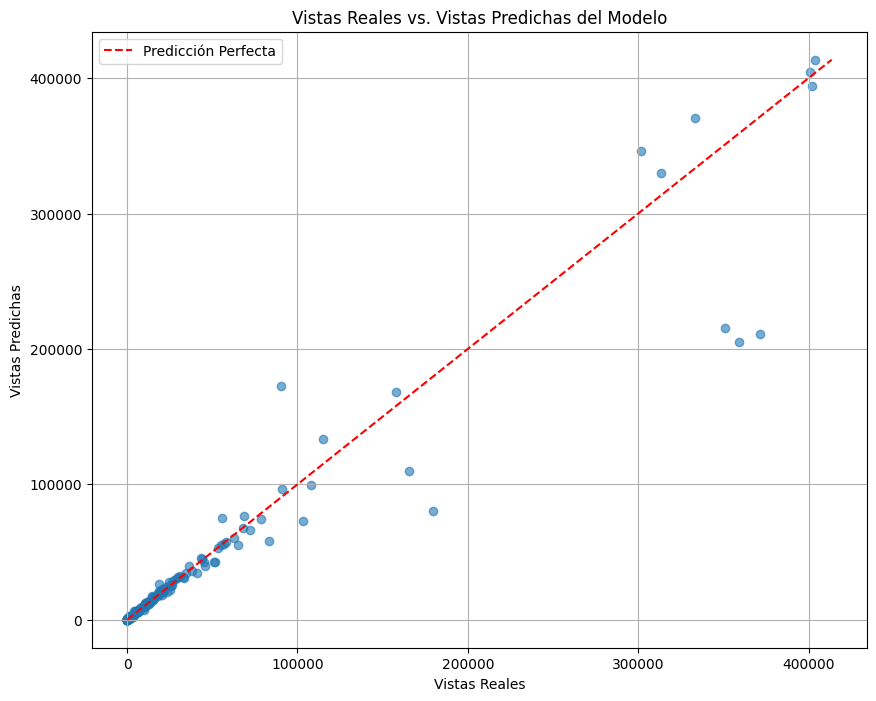

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Crear un gráfico de dispersión
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6)

# Añadir etiquetas y título
plt.xlabel('Vistas Reales')
plt.ylabel('Vistas Predichas')
plt.title('Vistas Reales vs. Vistas Predichas del Modelo')

# Dibujar una línea diagonal para la predicción perfecta
# Determinar los valores mínimos y máximos para la línea diagonal
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción Perfecta')

plt.grid(True)
plt.legend()
plt.show()


El análsis a resultado muy efectivo para predecir el nº de visitas, ya que como vimos anteriormente, la grán mayoría de los vídeos son del mismo tipo, duración, etc.

## Bloque 2: Clustering de canales

Ya que los vídeos son parecidos, vamos a comprobar como son los canales. En el siguiente apartado, haremos un modelo de clustering para los canales para ver cuantos tipos distintos de canales hay.
Empezamos identificando las variables necesarias para el clustering:

In [ ]:
ch_clt = ch_fil[['subscribers', 'total_views', 'total_videos']]

print("Primeras 5 filas de ch_clustering_features:")
print(ch_clt.head())

Primeras 5 filas de ch_clustering_features:
   subscribers  total_views  total_videos
1      4860000    257598451           243
2      4010000    870967915          1897
3      2990000    178609297          1000
4      2080000     82120292          1740
5      1990000    628661984          1214


Una vez más, para no alterar tanto los datos trabajaremos con la lista de canales filtrada que elimina a "linus tech tips":

Buscamos valores nulos por si los hubiera:

In [ ]:
print("Valores nulos en ch_clt:")
print(ch_clt.isnull().sum())

Valores nulos en ch_clt:
subscribers     0
total_views     0
total_videos    0
dtype: int64


Escalamos los datos:

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inicializar el escalador
scaler = StandardScaler()

# Escalar las características
ch_scaled_features = scaler.fit_transform(ch_clt)

print("Primeras 5 filas de las características escaladas:")
print(ch_scaled_features[:5])


Primeras 5 filas de las características escaladas:
[[ 6.31296287  1.34957888 -0.30409213]
 [ 5.11314656  5.419217    0.4420831 ]
 [ 3.673367    0.82549463  0.03741612]
 [ 2.38885778  0.18530082  0.3712551 ]
 [ 2.26181841  3.81154412  0.13395875]]


Determinamos el nº óptimo de clusters:

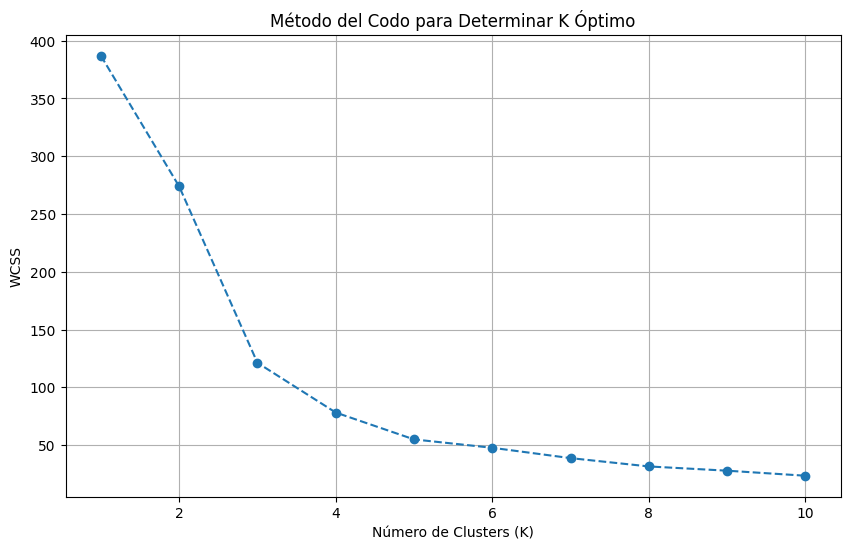

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 2. Inicializar una lista vacía para almacenar WCSS
wcss = []

# 3. Iterar a través de un rango de valores para k
for i in range(1, 11):
    # 4a. Inicializar KMeans
    # n_init='auto' para suprimir la advertencia y asegurar un buen resultado
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    # 4b. Ajustar el modelo a los datos escalados
    kmeans.fit(ch_scaled_features)
    # 4c. Añadir el valor de inertia_ (WCSS) a la lista
    wcss.append(kmeans.inertia_)

# 5. Crear un gráfico de línea
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')

# 6. Añadir etiquetas a los ejes
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')

# 7. Añadir un título al gráfico
plt.title('Método del Codo para Determinar K Óptimo')

# 8. Añadir una cuadrícula
plt.grid(True)

# 9. Mostrar el gráfico
plt.show()

Usando la gráfica de referencia, decidimos el nº de clusters

In [ ]:
from sklearn.cluster import KMeans

# 1. Elegir un número óptimo de clusters (K) basado en el gráfico del codo
# Observando el gráfico, el "codo" parece estar alrededor de K=4.
optimal_k = 4

# 2. Inicializar el modelo KMeans con el número óptimo de clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# 3. Ajustar el modelo a las características escaladas
kmeans.fit(ch_scaled_features)

# 4. Asignar las etiquetas de cluster al DataFrame 'ch_fil'
# La longitud de kmeans.labels_ (129) coincide con la longitud de ch_fil.
ch_fil.loc[:, 'cluster'] = kmeans.labels_

# 5. Mostrar las primeras filas del DataFrame 'ch_fil' con la nueva columna 'cluster'
print(f"Primeras 5 filas del DataFrame 'ch_fil' con la columna 'cluster' (K={optimal_k}):")
print(ch_fil.head())

Primeras 5 filas del DataFrame 'ch_fil' con la columna 'cluster' (K=4):
                 channel_id           channel_name  \
1  UCWv7vMbMWH4-V0ZXdmDpPBA  Programming with Mosh   
2  UChIZGfcnjHI0DG4nweWEduw             TechSource   
3  UC4SVo0Ue36XCfOyb5Lh1viQ               Bro Code   
4  UCVeW9qkBjo3zosnqUbG7CFw           John Hammond   
5  UCeeFfhMcJa1kjtfZAGskOCA             TechLinked   

                                         description  subscribers  \
1  Hi! I'm Mosh 👋, a software engineer with over ...      4860000   
2  Join the Discord Server:\nhttps://discord.gg/T...      4010000   
3                     Coding bootcamps HATE HIM! 🗿\n      2990000   
4  Free Cybersecurity Education and Ethical Hacking.      2080000   
5  TechLinked keeps you up to date with a fast, f...      1990000   

   total_views  total_videos                 created_date country  \
1    257598451           243         2014-10-07T00:40:53Z      US   
2    870967915          1897         2010-01-24T22

/tmp/ipython-input-64421440.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ch_fil.loc[:, 'cluster'] = kmeans.labels_


Una vez hecho el clustering, lo graficamos:

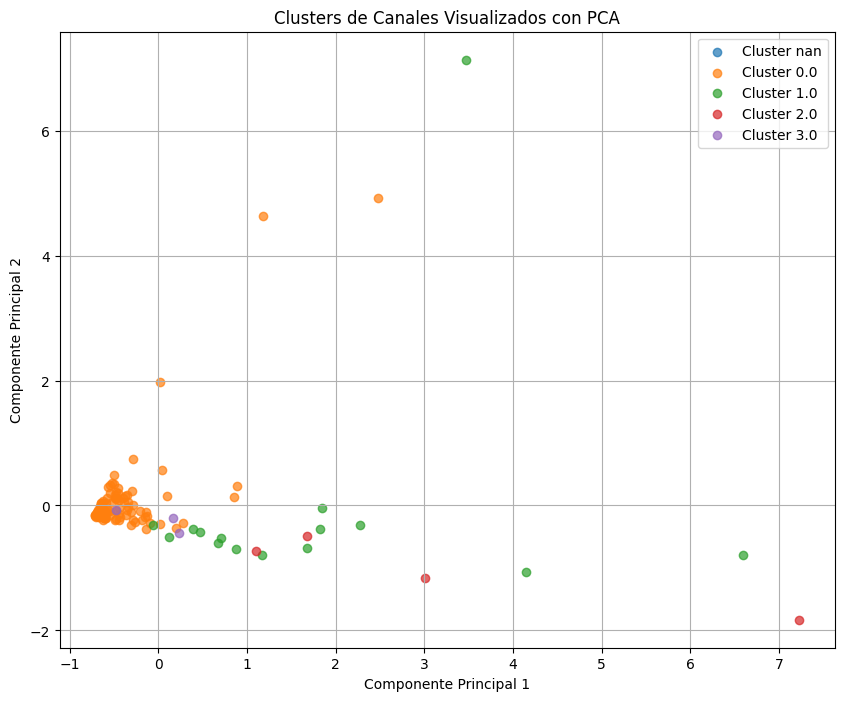

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 1. Inicializar PCA con 2 componentes
pca = PCA(n_components=2, random_state=42)

# 2. Aplicar PCA a las características escaladas
pca_features = pca.fit_transform(ch_scaled_features)

# 3. Crear un DataFrame de pandas a partir de pca_features
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])

# 4. Añadir la columna 'cluster' del DataFrame 'ch_fil' al nuevo DataFrame de PCA
pca_df['cluster'] = ch_fil['cluster']

# 5. Crear un gráfico de dispersión para visualizar los clusters
plt.figure(figsize=(10, 8))
for cluster_id in sorted(pca_df['cluster'].unique()):
    subset = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster_id}', alpha=0.7)

# 6. Añadir etiquetas y título
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters de Canales Visualizados con PCA')

# 7. Incluir una leyenda
plt.legend()

# 8. Añadir una cuadrícula
plt.grid(True)

# 9. Mostrar el gráfico
plt.show()

Parece que aunque 4 clusters sea el óptimo, la grán mayoría de los vídeos se congregan en el cluster 0, el de los vídeos cortos y pocas interacciones

## Bloque 3: Análisis de sentimiento de los vídeos

Como último análisis vamos a tomar los títulos de los vídeos y hacer análsis de seintimiento del mismo para ver qué tipo de vídeos son los más populares

Cogemos del dataframe unificado los títulos de los vídeos:

In [ ]:
titles_for_sentiment = df_unif['title']

print("Valores nulos antes de la imputación:")
print(titles_for_sentiment.isnull().sum())

# Rellenar valores nulos con una cadena vacía
titles_for_sentiment = titles_for_sentiment.fillna('')

# Asegurar que todos los títulos sean de tipo string
titles_for_sentiment = titles_for_sentiment.astype(str)

print("Valores nulos después de la imputación y conversión a string:")
print(titles_for_sentiment.isnull().sum())
print("Tipo de datos de 'titles_for_sentiment':", titles_for_sentiment.dtype)
print("Primeros 5 títulos para análisis de sentimiento:")
print(titles_for_sentiment.head())

Valores nulos antes de la imputación:
0
Valores nulos después de la imputación y conversión a string:
0
Tipo de datos de 'titles_for_sentiment': object
Primeros 5 títulos para análisis de sentimiento:
0     AI Course for Developers - Build AI-Powered Apps
1    AI Course for Developers – Build AI-Powered Ap...
2    A Practical AI Course for Developers is Coming...
3            Microsoft laid off 6,000 people… but why?
4    Spring Boot Project: Build a REST API for an E...
Name: title, dtype: object


Aplicamos el analizador de sentimientos VADER en los datos recogidos y los graficamos:

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Descargar el léxico VADER si aún no está disponible
# Solo se necesita ejecutar una vez
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError: # Catch LookupError instead of nltk.downloader.DownloadError
    nltk.download('vader_lexicon')

# Inicializar el SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Definir una función para obtener la puntuación de sentimiento compuesto
def get_sentiment_score(text):
    return sia.polarity_scores(text)['compound']

# Aplicar la función a la serie titles_for_sentiment
df_unif['sentiment_score'] = titles_for_sentiment.apply(get_sentiment_score)

print("Primeras filas del DataFrame merged_df con la nueva columna 'sentiment_score':")
print(df_unif[['title', 'sentiment_score']].head())

print("\nEstadísticas descriptivas de la columna 'sentiment_score':")
print(df_unif['sentiment_score'].describe())

Primeras filas del DataFrame merged_df con la nueva columna 'sentiment_score':
                                               title  sentiment_score
0   AI Course for Developers - Build AI-Powered Apps              0.0
1  AI Course for Developers – Build AI-Powered Ap...              0.0
2  A Practical AI Course for Developers is Coming...              0.0
3          Microsoft laid off 6,000 people… but why?              0.0
4  Spring Boot Project: Build a REST API for an E...              0.0

Estadísticas descriptivas de la columna 'sentiment_score':
count    1290.000000
mean        0.071125
std         0.263905
min        -0.831600
25%         0.000000
50%         0.000000
75%         0.102700
max         0.883200
Name: sentiment_score, dtype: float64


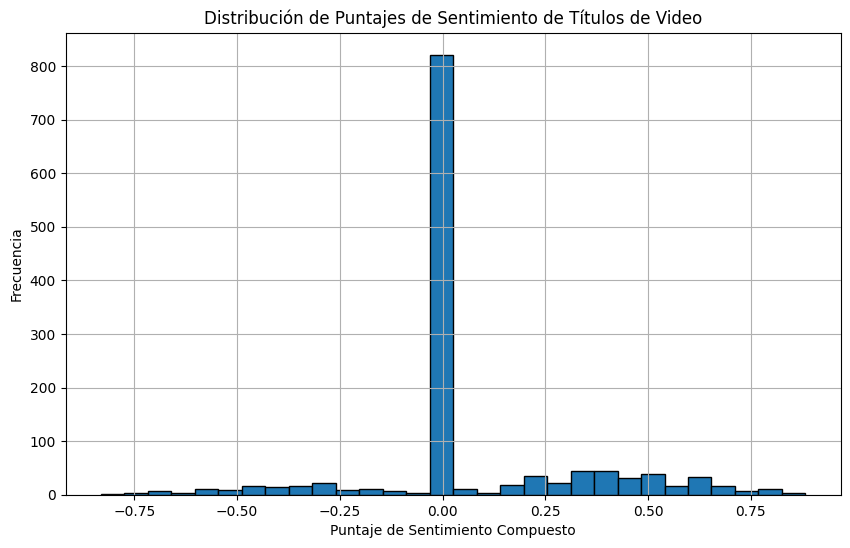

In [ ]:
import matplotlib.pyplot as plt

# 1. Crear un histograma de la columna `sentiment_score`
plt.figure(figsize=(10, 6))
df_unif['sentiment_score'].hist(bins=30, edgecolor='black')

# 2. Añadir etiquetas para el eje X y el eje Y
plt.xlabel('Puntaje de Sentimiento Compuesto')
plt.ylabel('Frecuencia')

# 3. Añadir un título al gráfico
plt.title('Distribución de Puntajes de Sentimiento de Títulos de Video')

# 4. Asegurar que el gráfico sea de un tamaño adecuado para la visualización (ya hecho con figsize)

# 5. Mostrar el gráfico
plt.grid(True)
plt.show()

El análisis de sentimiento muestra una cantidad avasalladora de lenguaje totalmente neutral, con títulos que parecen ser más descripciones objetivas del vídeo que "clickbait" para atraer visitas.

Una vez hecho esto, introducimos los datos en nuestro dataframe de la siguiente forma:

In [ ]:
import numpy as np

# 1. Definir una función para clasificar el sentimiento
def classify_sentiment(score):
    if score > 0:
        return 'positivo'
    elif score < 0:
        return 'negativo'
    else:
        return 'neutro'

# 2. Aplicar la función para crear la nueva columna 'sentiment_category'
df_unif['sentiment_category'] = df_unif['sentiment_score'].apply(classify_sentiment)

# 3. Calcular y mostrar los recuentos de cada categoría de sentimiento
sentiment_counts = df_unif['sentiment_category'].value_counts()
print("\nRecuentos de cada categoría de sentimiento:")
print(sentiment_counts)

# 4. Calcular y mostrar los porcentajes de cada categoría de sentimiento
sentiment_percentages = df_unif['sentiment_category'].value_counts(normalize=True) * 100
print("\nPorcentajes de cada categoría de sentimiento:")
print(sentiment_percentages)

# 5. Calcular y mostrar las estadísticas descriptivas del sentiment_score para cada sentiment_category
sentiment_stats = df_unif.groupby('sentiment_category')['sentiment_score'].describe()
print("\nEstadísticas descriptivas de los puntajes de sentimiento por categoría:")
print(sentiment_stats)


Recuentos de cada categoría de sentimiento:
sentiment_category
neutro      821
positivo    336
negativo    133
Name: count, dtype: int64

Porcentajes de cada categoría de sentimiento:
sentiment_category
neutro      63.643411
positivo    26.046512
negativo    10.310078
Name: proportion, dtype: float64

Estadísticas descriptivas de los puntajes de sentimiento por categoría:
                    count      mean       std     min     25%     50%     75%  \
sentiment_category                                                              
negativo            133.0 -0.388386  0.173034 -0.8316 -0.4939 -0.3612 -0.2732   
neutro              821.0  0.000000  0.000000  0.0000  0.0000  0.0000  0.0000   
positivo            336.0  0.426807  0.181845  0.0258  0.2960  0.4207  0.5565   

                       max  
sentiment_category          
negativo           -0.0516  
neutro              0.0000  
positivo            0.8832  


Con los gráficos ya incluidos en el dataframe, vamos a ver qué cantidad de cada tipo hay:

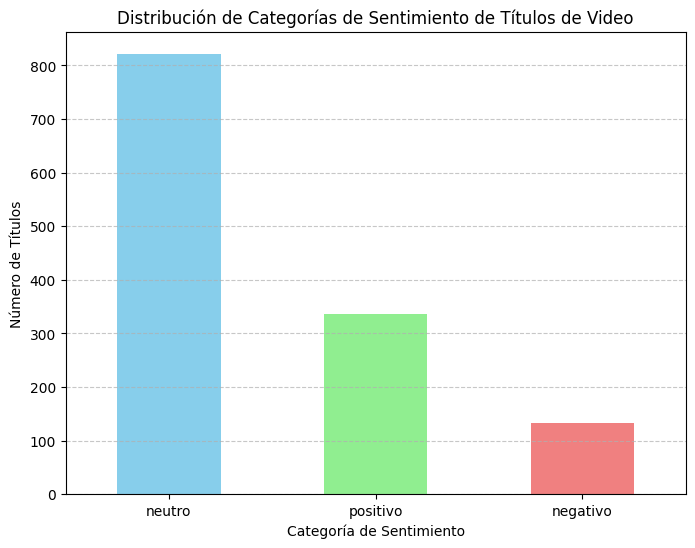

In [ ]:
import matplotlib.pyplot as plt

# 1. Crear un gráfico de barras utilizando los recuentos de categorías de sentimiento
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'lightcoral'])

# 2. Añadir etiquetas para el eje X y el eje Y
plt.xlabel('Categoría de Sentimiento')
plt.ylabel('Número de Títulos')

# 3. Añadir un título al gráfico
plt.title('Distribución de Categorías de Sentimiento de Títulos de Video')

# 4. Asegurar que el gráfico sea de un tamaño adecuado para la visualización (ya hecho con figsize)

# 5. Mostrar el gráfico
plt.xticks(rotation=0) # Para que las etiquetas del eje X no se superpongan
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Como se mencionó antes, la Cantidad de lenguaje clasificado como neutral es mucho más grande que la positiva o la negativa.

#Bloque 4: interpretabilidad de datos

Nos interesa también ver qué criterios han seguido los modelos de ML para valorar sus aportaciones:

###Interpretabilidad del Modelo de Regresión con LIME

In [ ]:
!pip install lime

In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd

# 1. Seleccionar una instancia para explicar del conjunto de prueba
# Escogemos la primera instancia de X_test para la explicación
instance_idx = 0
x_to_explain = X_test.iloc[instance_idx].values
original_prediction = model.predict(X_test.iloc[instance_idx].to_frame().T)

print(f"Instancia seleccionada para explicar (primeras 5 características):\n{x_to_explain[:5]}")
print(f"Predicción original del modelo para esta instancia: {original_prediction[0]:.2f}")

# 2. Crear una función de predicción para LIME
# LIME espera una función que tome un array 2D de NumPy (muestras x características)
# y devuelva un array 1D de predicciones para cada muestra.
predict_fn_lime = lambda x: model.predict(x)

# 3. Inicializar el explainer de LIME
# Es importante pasar los datos de entrenamiento (X_train.values) para que LIME pueda
# aprender la distribución de las características.
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['views'], # Para regresión, el nombre de la clase es el nombre de la variable objetivo
    mode='regression'
)

# 4. Explicar la instancia
explanation = explainer.explain_instance(
    data_row=x_to_explain,
    predict_fn=predict_fn_lime,
    num_features=10 # Mostrar las 10 características más importantes
)

# 5. Visualizar la explicación
print("\nExplicación de LIME para la instancia seleccionada:")
explanation.show_in_notebook(show_all=False)

Instancia seleccionada para explicar (primeras 5 características):
[np.float64(-0.1074455402545479) np.float64(-0.1693253631756224)
 np.float64(-0.5196380878980789) np.float64(-0.28368711461353)
 np.float64(-0.26529462459550873)]
Predicción original del modelo para esta instancia: 6376.30

Explicación de LIME para la instancia seleccionada:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.linear_model import LinearRegression
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd

# --- 1. Entrenar un nuevo modelo de Regresión Lineal ---
print("\n--- Entrenando Modelo de Regresión Lineal ---")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# --- 2. Preparar predicción para LIME para el modelo lineal ---
predict_fn_lime_linear = lambda x: linear_model.predict(x)

# --- 3. Generar explicación LIME para el modelo lineal (misma instancia) ---
explainer_linear = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['views'],
    mode='regression'
)

explanation_linear = explainer_linear.explain_instance(
    data_row=x_to_explain,
    predict_fn=predict_fn_lime_linear,
    num_features=10
)

original_prediction_linear = linear_model.predict(X_test.iloc[instance_idx].to_frame().T)
print(f"Predicción del Modelo Lineal para la misma instancia: {original_prediction_linear[0]:.2f}")
print("\n--- Explicación LIME para el Modelo de Regresión Lineal ---")
explanation_linear.show_in_notebook(show_all=False)

print("\n--- Explicación LIME para el Modelo Random Forest (reimprimiendo para comparación) ---")
explanation.show_in_notebook(show_all=False)



--- Entrenando Modelo de Regresión Lineal ---
Predicción del Modelo Lineal para la misma instancia: 317170.39

--- Explicación LIME para el Modelo de Regresión Lineal ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



--- Explicación LIME para el Modelo Random Forest (reimprimiendo para comparación) ---


Estos gráficos de barras muestran las 10 características más influyentes (según LIME) para la predicción de cada modelo para la instancia seleccionada.

*   Las barras verdes indican una contribución positiva a la predicción de vistas.
*   Las barras rojas/salmón indican una contribución negativa a la predicción de vistas.

Al comparar ambos gráficos, podemos observar visualmente qué características son más determinantes para cada modelo y en qué dirección, así como las diferencias en la magnitud de su influencia:

In [ ]:
# Extraer los pesos de las características para el modelo Random Forest
rf_lime_weights = explanation.as_list()

print("\n--- Pesos de las características (LIME) para Random Forest ---")
for feature, weight in rf_lime_weights:
    print(f"Característica: {feature}, Peso: {weight:.4f}")


--- Pesos de las características (LIME) para Random Forest ---
Característica: -0.12 < likes <= -0.09, Peso: -292895.1663
Característica: country_IE <= 0.00, Peso: -271924.1641
Característica: country_DK <= 0.00, Peso: -164154.2852
Característica: country_ID <= 0.00, Peso: 130526.2162
Característica: country_BG <= 0.00, Peso: -127495.9110
Característica: country_SG <= 0.00, Peso: 126417.9637
Característica: country_RU <= 0.00, Peso: 113402.8849
Característica: country_MT <= 0.00, Peso: 91198.8881
Característica: country_JP <= 0.00, Peso: 90482.6935
Característica: country_CA <= 0.00, Peso: -61003.7466


In [ ]:
# Extraer los pesos de las características para el modelo de Regresión Lineal
linear_lime_weights = explanation_linear.as_list()

print("\n--- Pesos de las características (LIME) para Regresión Lineal ---")
for feature, weight in linear_lime_weights:
    print(f"Característica: {feature}, Peso: {weight:.4f}")


--- Pesos de las características (LIME) para Regresión Lineal ---
Característica: -0.12 < likes <= -0.09, Peso: -986555.9845
Característica: country_SG <= 0.00, Peso: -839419.6702
Característica: country_DK <= 0.00, Peso: -748909.2755
Característica: country_IE <= 0.00, Peso: -685110.3237
Característica: country_HR <= 0.00, Peso: 648569.1106
Característica: -0.18 < comments <= -0.16, Peso: 569819.5336
Característica: country_FI <= 0.00, Peso: -546649.6415
Característica: country_NO <= 0.00, Peso: -536876.4985
Característica: country_ES <= 0.00, Peso: -479734.4635
Característica: country_KE <= 0.00, Peso: -431480.7290


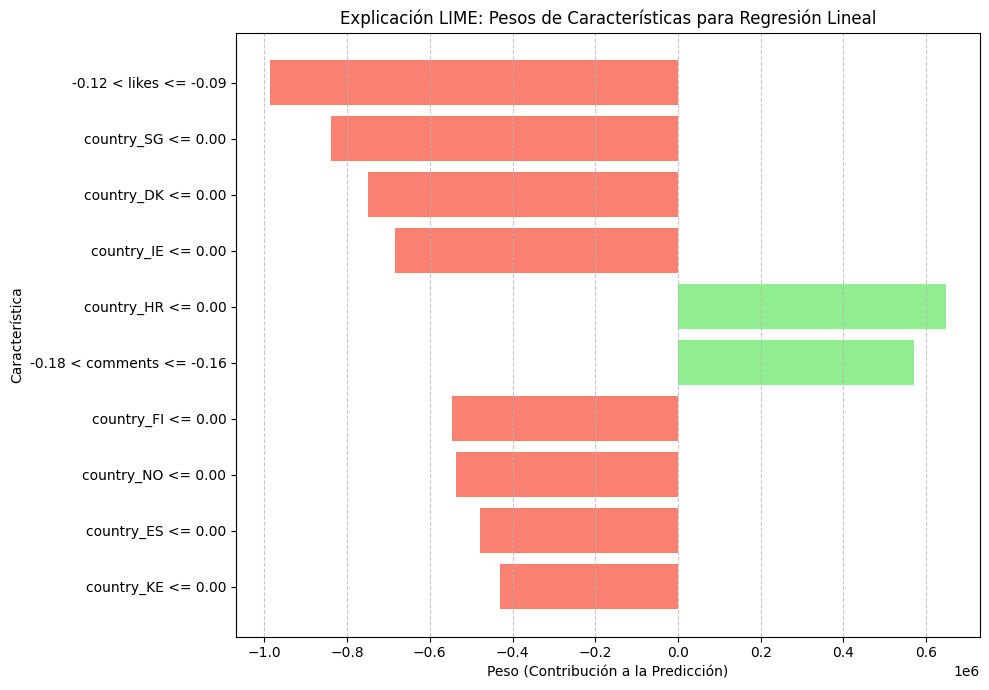

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir la lista de pesos de LIME a un DataFrame para facilitar la visualización
linear_weights_df = pd.DataFrame(linear_lime_weights, columns=['Feature', 'Weight'])

# Ordenar por el valor absoluto del peso para resaltar las características más importantes
linear_weights_df = linear_weights_df.reindex(linear_weights_df['Weight'].abs().sort_values().index)

# Crear el gráfico de barras
plt.figure(figsize=(10, 7))
plt.barh(linear_weights_df['Feature'], linear_weights_df['Weight'], color=['salmon' if x < 0 else 'lightgreen' for x in linear_weights_df['Weight']])
plt.xlabel('Peso (Contribución a la Predicción)')
plt.ylabel('Característica')
plt.title('Explicación LIME: Pesos de Características para Regresión Lineal')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

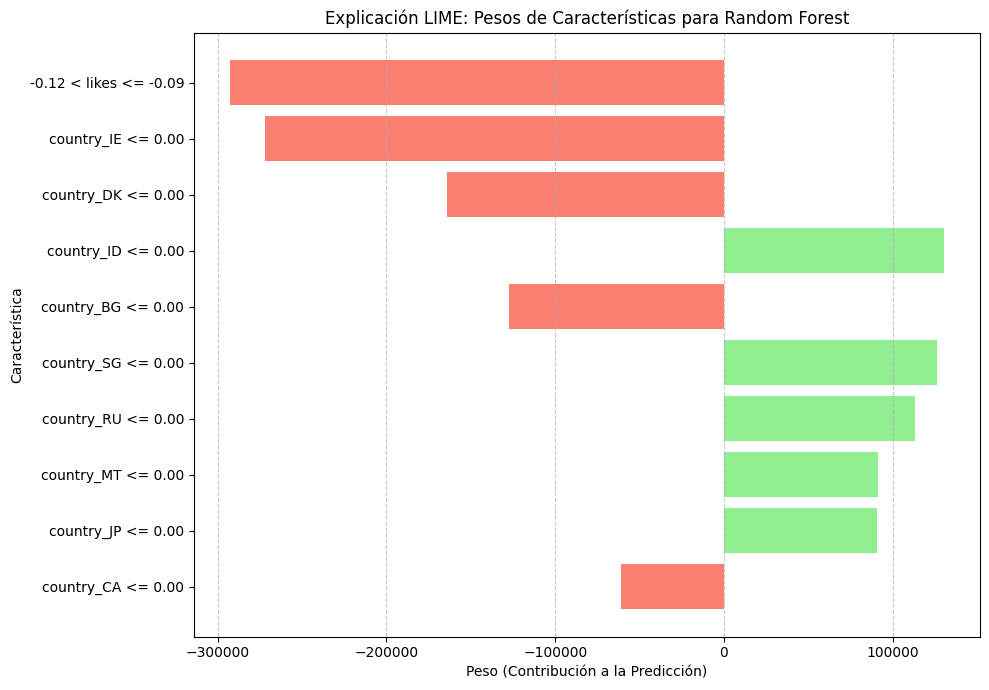

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir la lista de pesos de LIME a un DataFrame para facilitar la visualización
rf_weights_df = pd.DataFrame(rf_lime_weights, columns=['Feature', 'Weight'])

# Ordenar por el valor absoluto del peso para resaltar las características más importantes
rf_weights_df = rf_weights_df.reindex(rf_weights_df['Weight'].abs().sort_values().index)

# Crear el gráfico de barras
plt.figure(figsize=(10, 7))
plt.barh(rf_weights_df['Feature'], rf_weights_df['Weight'], color=['salmon' if x < 0 else 'lightgreen' for x in rf_weights_df['Weight']])
plt.xlabel('Peso (Contribución a la Predicción)')
plt.ylabel('Característica')
plt.title('Explicación LIME: Pesos de Características para Random Forest')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

En el modelo de regresión lineal, la cantidad de comenatarios parece la variable con más peso, mientras que en el random forest tiene también en cuenta que los vídeos sean de paises donde no hay muchos canales de este tipo, como por ejemplo Malta.

##Conclusiones

El estudio mediante ML ha revelado qué nuestra conjetura de la actividad anterior era la correcta: los canales más abundantes de tecnología son aquellos que son pequeños, con pocas visitas y con pocas interacciones.
En el 1er modelo, pudimos ver que limpiando el dataframe del dato anómalo, la regresión lineal nos daba casí por completo vídeos con views bastante limitadas, con pocos valores saliendose de la línea.

Este dato se acentuó en el 2º ML, ddonde el clustering de los datos filtrados reveló que el canal promedio del scrapeo del que salieron estos datos eran canales pequeños, con pocas visitas, pocos seguidores  pocos comentarios.

Por último, para afianzar más el resultado del estudio, realizamos un análisis de sentimiento de los titulos de los vídeos. Aplicando los procedimientos necesarios, se vio que el lenguaje neutral era mucho más abundante que el negativo o el positivo, reflejando que la mayoría de vídeos no son de opiniones sobre tecnología, si no vídeos cortos de intrucciones precisas, vídeos que raramente se ven más de una vez. Dichas características hacen que la mayoría de los canales no tengn un nº alto de suscriptores, ya que son videos "de usar y tirar".

Por otra parte, de los vídeos que sí son de opiniones parecen tener un lider claro: Linus tech tips, canal fundado en 2008, habla sobre noticias y nuevos prodctos de tecnología dando su opinión al respecto. El resto de canales de esta índole no pueden acercarse a sus nº, ya sea por antigüedad o por fama. Tal era la influencia de este canal sobre el conjunto de los datos, que intentar hacer la regresión lineal incluyéndolo en los datos daba como resultado un R^2 de -0.19 a -0.43, anulando totalmente el objetivo del proceso del ML.